# 06 — DENSITÉ PIÉTONNE × WALK INDEX — GRAND GENÈVE

Agrège `density_all.tif` (notebook 03) sur deux maillages — carreaux 200 m et zones infra-communales — avec **exactextract** (pondération par la fraction de pixel couverte), puis produit pour chacun :

- la carte de densité agrégée (écrêtage P99 ou P95)
- une bivariate choropleth 3×3 densité × walk index (catégories ≤P25 / entre / ≥P75)
- les quadrants densité × walk index, zones critiques (walk = 1, densité = 3) en rouge

et exporte le walk index enrichi en `.parquet` + `.gpkg`.

In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# FONCTIONS — densité piétonne agrégée × walk index (Grand Genève)
# ══════════════════════════════════════════════════════════════════════════════
import os
import sys
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.io import MemoryFile
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize, LogNorm, LinearSegmentedColormap
from matplotlib.lines import Line2D
from sklearn.preprocessing import MinMaxScaler
from exactextract import exact_extract

warnings.filterwarnings("ignore", category=UserWarning)

import sys
import os
sys.path.insert(0, os.path.abspath("../.."))

import sys
import os
sys.path.insert(0, os.path.abspath("../.."))

from utils.config import *
from utils.functions import *

# ─── Chargement ───────────────────────────────────────────────────────────────
def load_raster(output_path, raster_name, return_profile=False):
    """
    Charge un GeoTIFF exporté (ex. density_all.tif).

    Parameters
    ----------
    output_path    : str  → dossier contenant le raster
    raster_name    : str  → nom du fichier sans extension
    return_profile : bool → si True, retourne aussi le profil rasterio (crs, transform, ...)

    Returns
    -------
    np.ndarray (float32)            si return_profile=False
    (np.ndarray, dict)              si return_profile=True
    None / (None, None)             si le fichier n'existe pas
    """
    filepath = os.path.join(output_path, f"{raster_name}.tif")
    if not os.path.exists(filepath):
        print(f"  ⚠ Fichier introuvable : {filepath}")
        return (None, None) if return_profile else None
    with rasterio.open(filepath) as src:
        arr = src.read(1)
        profile = src.profile.copy()
    return (arr, profile) if return_profile else arr


def read_zones(path, crs="EPSG:2056"):
    """Lit un maillage (.parquet, .gpkg, .shp, ...) et le reprojette dans `crs`."""
    gdf = gpd.read_parquet(path) if str(path).endswith(".parquet") else gpd.read_file(path)
    return gdf.to_crs(crs)


# ─── Agrégation raster → zones (exactextract) ─────────────────────────────────
def aggregate_raster_to_area_exact(zones_gdf, raster_paths, nan_as_zero=False,
                                   normalize=True, verbose=True):
    """
    Enrichit zones_gdf avec la densité piétonne moyenne par zone, calculée avec
    exactextract : chaque pixel est pondéré par la fraction de sa surface
    réellement couverte par la zone (pas de règle « centre du pixel »).

    Modifie zones_gdf in-place et le retourne.

    Parameters
    ----------
    zones_gdf    : GeoDataFrame → zones (reprojetées à la volée dans le CRS du raster)
    raster_paths : dict         → {group_name: chemin du .tif}, ex. {"all": ".../density_all.tif"}
    nan_as_zero  : bool         → False (défaut) : les pixels NaN/nodata sont EXCLUS de la moyenne
                                  (moyenne sur la seule partie valide de la zone).
                                  True : les pixels NaN/nodata comptent comme 0
                                  (moyenne sur toute la surface de la zone ; une zone
                                  entièrement hors périmètre reçoit alors 0 au lieu de NaN).
    normalize    : bool         → ajoute density_<g>_norm (MinMax sur les zones non-NaN)
    verbose      : bool

    Colonnes créées (pour chaque groupe g)
    --------------------------------------
    density_<g>      : moyenne pondérée par la couverture  Σ cᵢ·xᵢ / Σ cᵢ
    n_pixels_<g>     : Σ cᵢ = nombre (décimal) de pixels utilisés
    valid_share_<g>  : part de la surface de la zone couverte par des pixels utilisés (0–1)
    density_<g>_norm : densité normalisée MinMax (si normalize=True)
    """
    geoms = zones_gdf[["geometry"]].copy()
    geoms["_eid"] = np.arange(len(geoms))

    for group_name, path in raster_paths.items():
        if verbose:
            mode = "NaN → 0" if nan_as_zero else "NaN exclus"
            print(f"  Agrégation : {group_name}  ({mode})")

        with rasterio.open(path) as src:
            g = geoms.to_crs(src.crs) if geoms.crs != src.crs else geoms
            px_area = abs(src.res[0] * src.res[1])

            if not nan_as_zero:
                df = exact_extract(src, g, ["mean", "count"],
                                   include_cols=["_eid"], output="pandas")
            else:
                arr = src.read(1).astype("float32")
                invalid = np.isnan(arr)
                if src.nodata is not None and not np.isnan(src.nodata):
                    invalid |= (arr == src.nodata)
                arr[invalid] = 0.0
                prof = src.profile.copy()
                prof.update(dtype="float32", nodata=None)
                with MemoryFile() as mem:
                    with mem.open(**prof) as tmp:
                        tmp.write(arr, 1)
                    del arr
                    with mem.open() as tmp:
                        df = exact_extract(tmp, g, ["mean", "count"],
                                           include_cols=["_eid"], output="pandas")

        df = df.set_index("_eid").reindex(range(len(geoms)))
        zone_area_px = (g.geometry.area / px_area).to_numpy()

        col = f"density_{group_name}"
        zones_gdf[col]                        = df["mean"].astype(float).to_numpy()
        zones_gdf[f"n_pixels_{group_name}"]   = df["count"].fillna(0).astype(float).to_numpy()
        with np.errstate(divide="ignore", invalid="ignore"):
            zones_gdf[f"valid_share_{group_name}"] = np.clip(
                zones_gdf[f"n_pixels_{group_name}"].to_numpy() / zone_area_px, 0, 1)

        # ─── Normalisation MinMax ────────────────────────────────────────────
        if normalize:
            col_norm = f"{col}_norm"
            zones_gdf[col_norm] = np.nan
            valid = zones_gdf[col].notna()
            if valid.sum() > 0:
                zones_gdf.loc[valid, col_norm] = MinMaxScaler().fit_transform(
                    zones_gdf.loc[valid, [col]]).ravel()

        if verbose:
            n_nan = zones_gdf[col].isna().sum()
            print(f"    → {len(zones_gdf) - n_nan:,} zones avec valeur | {n_nan:,} NaN "
                  f"| valid_share médian = {np.nanmedian(zones_gdf[f'valid_share_{group_name}']):.2f}")

    return zones_gdf


# ─── Classes P25 / P75 ────────────────────────────────────────────────────────
# Palette bivariée 3×3 (J. Stevens) — clé = (classe densité, classe walk index)
# densité ↑ → rouge ; walk index ↑ → bleu ; (3, 1) = forte densité & faible walk = ROUGE
BIVAR_COLORS = {
    (1, 1): "#e8e8e8", (2, 1): "#e4acac", (3, 1): "#c85a5a",
    (1, 2): "#b0d5df", (2, 2): "#ad9ea5", (3, 2): "#985356",
    (1, 3): "#64acbe", (2, 3): "#627f8c", (3, 3): "#574249",
}
NODATA_COLOR   = "#f7f7f7"
CRITICAL_COLOR = "#d7301f"

def classify_p_low_high(series, p_low=25, p_high=75, active_only=False):
    """
    Classe une variable en 3 catégories :
      1 = valeur ≤ P_low | 2 = entre les deux | 3 = valeur ≥ P_high | <NA> si NaN.
    active_only=False : percentiles calculés sur toutes les zones non-NaN.
    active_only=True  : percentiles calculés sur les zones > 0 uniquement ;
                        les zones à 0 restent classées (→ catégorie 1).
    Retourne (classes: pd.Series Int64, (seuil_bas, seuil_haut)).
    """
    s = series.astype(float)
    ref = s[s > 0] if active_only else s
    lo, hi = np.nanpercentile(ref, [p_low, p_high])
    if lo == hi:
        print(f"  ⚠ {series.name}: P{p_low} == P{p_high} ({lo:.3g}) — beaucoup de valeurs identiques")
    cls = pd.Series(pd.NA, index=s.index, dtype="Int64")
    cls[s.notna()] = 2
    cls[s <= lo] = 1
    cls[s >= hi] = 3
    return cls, (lo, hi)

def add_bivariate_classes(gdf, density_col="density_all", walk_col="walk_index",
                          p_low=25, p_high=75, density_active_only=False, verbose=True):
    """
    Ajoute à gdf (in-place) :
      density_class, walk_class  : 1/2/3 (P_low / P_high)
      bivar_class                : "D{density}-W{walk}", ex. "D3-W1"
      is_critical                : True si walk_class == 1 et density_class == 3
    density_active_only : si True, les percentiles de densité sont calculés sur les
                          zones à densité > 0 uniquement (le walk index n'est pas concerné).
    Retourne un dict avec les seuils.
    """
    gdf["density_class"], d_thr = classify_p_low_high(gdf[density_col], p_low, p_high,
                                                      active_only=density_active_only)
    gdf["walk_class"],    w_thr = classify_p_low_high(gdf[walk_col],    p_low, p_high)

    both = gdf["density_class"].notna() & gdf["walk_class"].notna()
    gdf["bivar_class"] = pd.Series(pd.NA, index=gdf.index, dtype="string")
    gdf.loc[both, "bivar_class"] = ("D" + gdf.loc[both, "density_class"].astype(str)
                                    + "-W" + gdf.loc[both, "walk_class"].astype(str))
    gdf["is_critical"] = ((gdf["density_class"] == 3) & (gdf["walk_class"] == 1)).fillna(False).astype(bool)

    thresholds = {"density": d_thr, "walk": w_thr, "p_low": p_low, "p_high": p_high,
                  "density_active_only": density_active_only}
    if verbose:
        ref = "zones > 0" if density_active_only else "toutes zones"
        print(f"  Seuils densité calculés sur : {ref}")
        print(f"  Seuils {density_col:>14s} : P{p_low} = {d_thr[0]:.4g} | P{p_high} = {d_thr[1]:.4g}")
        print(f"  Seuils {walk_col:>14s} : P{p_low} = {w_thr[0]:.4g} | P{p_high} = {w_thr[1]:.4g}")
        ct = pd.crosstab(gdf["walk_class"], gdf["density_class"],
                         rownames=["walk ↓ / density →"], colnames=[""]).sort_index(ascending=False)
        print(ct.to_string())
        print(f"  → zones critiques (walk=1, density=3) : {gdf['is_critical'].sum():,}")
    return thresholds


def _draw_context(ax, boundary=None, lake=None):
    if lake is not None:
        lake.plot(ax=ax, color="#dbe9f4", edgecolor="none", zorder=0)
    if boundary is not None:
        boundary.boundary.plot(ax=ax, color="black", linewidth=0.8, zorder=5)


def _normalize_q(clip_quantile):
    if clip_quantile is None:
        return None
    return clip_quantile / 100 if clip_quantile > 1 else clip_quantile


# ─── Plot densité agrégée ─────────────────────────────────────────────────────
def plot_aggregated_density(gdf, col="density_all", clip_quantile=0.99, log_scale=False,
                            title=None, boundary=None, lake=None, cmap=None,
                            edgecolor="none", linewidth=0.0, figsize=(10, 10), ax=None):
    """
    Choroplèthe de la densité piétonne agrégée par zone.

    clip_quantile : 0.99 / 0.95 (ou 99 / 95) → valeurs au-dessus écrêtées à ce quantile
                    (colorbar avec flèche « max ») ; None = pas d'écrêtage.
    log_scale     : échelle de couleur logarithmique (zones à 0 affichées en gris clair).
    """
    q = _normalize_q(clip_quantile)
    vals = gdf[col].astype(float)
    vmax = vals.quantile(q) if q is not None else vals.max()
    plot_vals = vals.clip(upper=vmax)

    if cmap is None:
        cmap = LinearSegmentedColormap.from_list("magma_trunc", plt.cm.magma(np.linspace(0.15, 1.0, 256)))

    if log_scale:
        pos = plot_vals[plot_vals > 0]
        norm = LogNorm(vmin=pos.min(), vmax=vmax)
        plot_vals = plot_vals.where(plot_vals > 0)          # 0 → NaN (gris)
    else:
        norm = Normalize(vmin=0, vmax=vmax)

    created = ax is None
    if created:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure
    _draw_context(ax, None, lake)
    tmp = gdf[["geometry"]].copy()
    tmp["_v"] = plot_vals.to_numpy()
    tmp[tmp["_v"].isna()].plot(ax=ax, color=NODATA_COLOR, edgecolor=edgecolor, linewidth=linewidth, zorder=1)
    tmp[tmp["_v"].notna()].plot(ax=ax, column="_v", cmap=cmap, norm=norm,
                                edgecolor=edgecolor, linewidth=linewidth, zorder=2)
    _draw_context(ax, boundary, None)

    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    extend = "max" if (q is not None and vals.max() > vmax) else "neither"
    cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.01, extend=extend)
    clip_lbl = f" — écrêté à P{round(q * 100)}" if q is not None else ""
    cbar.set_label(f"{col}{' (log)' if log_scale else ''}{clip_lbl}", size=11)

    ax.set_title(title or f"Densité piétonne agrégée — {col}", fontsize=13)
    ax.set_axis_off()
    if created:
        plt.tight_layout()
        plt.show()
    return ax


# ─── Plot bivariate choropleth 3×3 ───────────────────────────────────────────
def _bivar_legend(fig, rect, density_label, walk_label, p_low, p_high):
    lax = fig.add_axes(rect)
    for (d, w), c in BIVAR_COLORS.items():
        lax.add_patch(mpatches.Rectangle((d - 1, w - 1), 1, 1, facecolor=c, edgecolor="white", linewidth=1.5))
    lax.add_patch(mpatches.Rectangle((2, 0), 1, 1, fill=False, edgecolor=CRITICAL_COLOR, linewidth=2))
    lax.set_xlim(0, 3); lax.set_ylim(0, 3)
    lax.set_aspect("equal")
    lax.set_xticks([0.5, 1.5, 2.5]); lax.set_xticklabels([f"≤P{p_low}", "", f"≥P{p_high}"], fontsize=8)
    lax.set_yticks([0.5, 1.5, 2.5]); lax.set_yticklabels([f"≤P{p_low}", "", f"≥P{p_high}"], fontsize=8)
    lax.set_xlabel(f"{density_label} →", fontsize=9)
    lax.set_ylabel(f"{walk_label} →", fontsize=9)
    lax.yaxis.set_label_coords(-0.55, 0.5)
    lax.tick_params(length=0)
    for s in lax.spines.values():
        s.set_visible(False)
    return lax


def plot_bivariate_choropleth(gdf, density_col="density_all", walk_col="walk_index",
                              p_low=25, p_high=75, title=None, boundary=None, lake=None,
                              density_label="Densité piétonne", walk_label="Walk index",
                              edgecolor="none", linewidth=0.0, figsize=(11, 10),
                              legend_rect=(0.76, 0.10, 0.16, 0.16),
                              density_active_only=False, verbose=True):
    """
    Carte bivariée 3×3 : densité piétonne (axe rouge) × walk index (axe bleu).
    Catégories : 1 = ≤ P_low, 2 = entre, 3 = ≥ P_high (calculées sur le maillage).
    La case (densité 3, walk 1) — zones critiques — est rouge et encadrée dans la légende.

    Ajoute density_class, walk_class, bivar_class, is_critical à gdf (in-place).
    Retourne le dict des seuils.
    """
    thr = add_bivariate_classes(gdf, density_col, walk_col, p_low, p_high,
                                density_active_only=density_active_only, verbose=verbose)
    fig, ax = plt.subplots(figsize=figsize)
    fig.subplots_adjust(left=0.02, right=0.72, top=0.93, bottom=0.03)
    _draw_context(ax, None, lake)
    no_data = gdf["bivar_class"].isna()
    if no_data.any():
        gdf[no_data].plot(ax=ax, color=NODATA_COLOR, edgecolor=edgecolor, linewidth=linewidth, zorder=1)
    colors = [BIVAR_COLORS[(int(d), int(w))] for d, w in
              zip(gdf.loc[~no_data, "density_class"], gdf.loc[~no_data, "walk_class"])]
    gdf[~no_data].plot(ax=ax, color=colors, edgecolor=edgecolor, linewidth=linewidth, zorder=2)
    _draw_context(ax, boundary, None)

    ax.set_title(title or f"{density_label} × {walk_label} — P{p_low}/P{p_high}", fontsize=13)
    ax.set_axis_off()
    _bivar_legend(fig, legend_rect, density_label, walk_label, p_low, p_high)
    if no_data.any():
        ax.legend(handles=[mpatches.Patch(color=NODATA_COLOR, label=f"Pas de donnée (n={no_data.sum():,})")],
                  loc="upper left", fontsize=9, frameon=False)
    plt.show()
    return thr


# ─── Plot quadrants : nuage de points + carte ────────────────────────────────
def plot_quadrant_scatter_map(gdf, density_col="density_all", walk_col="walk_index",
                              p_low=25, p_high=75, x_log=True, title=None,
                              boundary=None, lake=None,
                              density_label="Densité piétonne", walk_label="Walk index",
                              edgecolor="none", linewidth=0.0, figsize=(18, 8),
                              point_size=12, density_active_only=False, verbose=True):
    """
    À gauche : un point par zone (x = densité, y = walk index), lignes P_low / P_high,
               points critiques (walk = 1 & densité = 3) en rouge.
    À droite : carte des mêmes zones critiques en rouge, les autres en gris.

    x_log : axe des densités en log (les zones à densité 0 sont placées au bord gauche).
    Ajoute les classes à gdf (in-place) et retourne le dict des seuils.
    """
    thr = add_bivariate_classes(gdf, density_col, walk_col, p_low, p_high,
                                density_active_only=density_active_only, verbose=verbose)    
    d_lo, d_hi = thr["density"]
    w_lo, w_hi = thr["walk"]

    data = gdf[[density_col, walk_col, "is_critical"]].dropna(subset=[density_col, walk_col]).copy()
    x = data[density_col].astype(float).to_numpy()
    y = data[walk_col].astype(float).to_numpy()
    n_floor = 0
    if x_log:
        # les densités nulles / quasi nulles (queues du lissage gaussien) écraseraient l'axe :
        # tout ce qui est sous P1 des valeurs > 0 est ramené au bord gauche
        pos = x[x > 0]
        floor = np.percentile(pos, 1) / 2 if pos.size else 1e-12
        n_floor = int((x < floor).sum())
        x = np.maximum(x, floor)
    crit = data["is_critical"].to_numpy()

    fig, (ax_s, ax_m) = plt.subplots(1, 2, figsize=figsize, gridspec_kw={"width_ratios": [1, 1.1]})

    # ─── Nuage de points ─────────────────────────────────────────────────────
    ax_s.scatter(x[~crit], y[~crit], s=point_size, c="#9e9e9e", alpha=0.45, linewidths=0,
                 label=f"Autres zones (n={(~crit).sum():,})")
    ax_s.scatter(x[crit], y[crit], s=point_size * 1.6, c=CRITICAL_COLOR, alpha=0.9, linewidths=0,
                 label=f"Walk ≤P{p_low} & densité ≥P{p_high} (n={crit.sum():,})")
    for v in (d_lo, d_hi):
        if not (x_log and v <= 0):
            ax_s.axvline(v, color="black", linestyle="--", linewidth=0.8)
    for v in (w_lo, w_hi):
        ax_s.axhline(v, color="black", linestyle="--", linewidth=0.8)
    if x_log:
        ax_s.set_xscale("log")
    # zone critique ombrée (en bas à droite)
    x0, x1 = ax_s.get_xlim(); y0, y1 = ax_s.get_ylim()
    ax_s.fill_between([d_hi, x1], y0, w_lo, color=CRITICAL_COLOR, alpha=0.07, zorder=0)
    ax_s.set_xlim(x0, x1); ax_s.set_ylim(y0, y1)
    ax_s.set_xlabel(f"{density_label}{' (log)' if x_log else ''}", fontsize=11)
    ax_s.set_ylabel(walk_label, fontsize=11)
    ax_s.legend(loc="upper left", fontsize=9, framealpha=0.9)
    note = f"\n{n_floor:,} zones à densité ~0 (< P1/2 des valeurs > 0) placées au bord gauche" if n_floor else ""
    ax_s.set_title(f"Quadrants P{p_low}/P{p_high}{note}", fontsize=11)
    ax_s.grid(alpha=0.2)

    # ─── Carte ───────────────────────────────────────────────────────────────
    _draw_context(ax_m, None, lake)
    gdf[~gdf["is_critical"]].plot(ax=ax_m, color="#e6e6e6", edgecolor=edgecolor, linewidth=linewidth, zorder=1)
    gdf[gdf["is_critical"]].plot(ax=ax_m, color=CRITICAL_COLOR, edgecolor=edgecolor, linewidth=linewidth, zorder=2)
    _draw_context(ax_m, boundary, None)
    ax_m.set_axis_off()
    ax_m.set_title(f"Zones critiques (n={gdf['is_critical'].sum():,})", fontsize=11)

    fig.suptitle(title or f"{density_label} × {walk_label}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
    return thr


# ─── Export ───────────────────────────────────────────────────────────────────
def export_enriched(gdf, out_dir, name, crs=None):
    """Exporte gdf en .parquet et .gpkg dans out_dir (crs=None → CRS actuel)."""
    os.makedirs(out_dir, exist_ok=True)
    out = gdf.to_crs(crs) if crs is not None else gdf.copy()
    # types nullables → types simples (compatibilité GPKG / QGIS)
    for c in out.columns:
        if str(out[c].dtype) == "Int64":
            out[c] = out[c].astype("float64")
        elif str(out[c].dtype) == "string":
            out[c] = out[c].astype(object)
    p_parquet = os.path.join(out_dir, f"{name}.parquet")
    p_gpkg    = os.path.join(out_dir, f"{name}.gpkg")
    out.to_parquet(p_parquet)
    out.to_file(p_gpkg, driver="GPKG", layer=name)
    print(f"  ✓ {p_parquet}\n  ✓ {p_gpkg}  ({len(out):,} zones, {out.crs.to_string()})")
    return p_parquet, p_gpkg

print("✓ fonctions chargées")


✓ fonctions chargées


# PARAMÈTRES

In [13]:
# ─── Config projet ────────────────────────────────────────────────────────────
sys.path.insert(0, os.path.abspath("../.."))
try:
    from utils.config import output_file_path_PL, input_file_path, output_step3_geo_weighted_path
except ImportError:
    output_file_path_PL = "../../Data/output/PL_output/"   # ← adapter si besoin
    input_file_path     = "../../Data/input"
    output_step3_geo_weighted_path = "../../Data/output/step3_geo_weighted/"

operation_crs = "EPSG:2056"

# ─── Raster de densité (produit par 03_RASTER_WALK_DENSITY) ──────────────────
RASTER_DIR  = output_file_path_PL
RASTER_NAME = "density_all"
RASTER_PATHS = {"all": os.path.join(RASTER_DIR, f"{RASTER_NAME}.tif")}

# ─── Walk index agrégé — À REMPLIR ───────────────────────────────────────────
PATH_WALK_CARREAU200 = f"{output_step3_geo_weighted_path}/step3_aggregated_index_carreau200.gpkg"      # .gpkg / .parquet / .shp
PATH_WALK_INFRA      = f"{output_step3_geo_weighted_path}/step3_aggregated_index_gg_infra_communal.gpkg"
WALK_COL             = "walk_index"                                 # nom de la colonne walk index

# ─── Contexte cartographique (mêmes fichiers que le notebook 03) ─────────────
PATH_AGGLO = f"{input_file_path}/network_agreg/AGGLO_PERIMETRE_AVEC_LAC-SHP/AGGLO_PERIMETRE_AVEC_LAC.shp"
PATH_LAC   = f"{input_file_path}/network_agreg/LAC_LEMAN_WITHOUT_BRIDGE-SHP"

# ─── Paramètres d'analyse ────────────────────────────────────────────────────
NAN_AS_ZERO   = True   # False = NaN exclus de la moyenne (défaut) | True = NaN comptés comme 0
P_LOW, P_HIGH = 33, 66  # seuils des catégories 1 / 2 / 3
CLIP_Q        = 0.99    # écrêtage de la carte de densité : 0.99 ou 0.95 (None = aucun)
DENSITY_ACTIVE_ONLY = True
DENSITY_COL   = "density_all"

# ─── Export ──────────────────────────────────────────────────────────────────
OUTPUT_DIR = os.path.join(output_file_path_PL, "WALK_INDEX_DENSITY")
EXPORT_CRS = operation_crs   # ex. "EPSG:4326" pour rester cohérent avec les anciens exports


# IMPORTS

In [14]:
# ─── Raster densité : contrôle rapide ────────────────────────────────────────
density_all, profile = load_raster(RASTER_DIR, RASTER_NAME, return_profile=True)
valid = ~np.isnan(density_all)
print(f"{RASTER_NAME}.tif : {density_all.shape} | {profile['crs']} | pixel {profile['transform'].a:.0f} m")
print(f"  pixels valides : {valid.sum():,} | > 0 : {(density_all > 0).sum():,} | max : {np.nanmax(density_all):.4g}")
del density_all, valid

# ─── Maillages walk index ────────────────────────────────────────────────────
MESHES = {
    "carreau_200": read_zones(PATH_WALK_CARREAU200, operation_crs),
    "zones_infra": read_zones(PATH_WALK_INFRA,      operation_crs),
}
for name, gdf in MESHES.items():
    assert WALK_COL in gdf.columns, f"{WALK_COL} absent de {name}"
    clash = [c for c in gdf.columns if c.startswith(DENSITY_COL)]
    if clash:
        print(f"  ⚠ {name} : colonnes existantes écrasées → {clash}")
    print(f"{name:12s} : {len(gdf):,} zones | {WALK_COL} NaN : {gdf[WALK_COL].isna().sum():,}")

# ─── Contexte ────────────────────────────────────────────────────────────────
agglo_GG  = read_zones(PATH_AGGLO, operation_crs)
lac_leman = read_zones(PATH_LAC,   operation_crs)


density_all.tif : (6891, 6553) | EPSG:2056 | pixel 10 m
  pixels valides : 19,885,278 | > 0 : 3,782,275 | max : 0.02541
carreau_200  : 40,946 zones | walk_index NaN : 0
zones_infra  : 743 zones | walk_index NaN : 0


# AGRÉGATION DENSITÉ → MAILLAGES (exactextract)

`NAN_AS_ZERO=False` : les pixels hors périmètre / lac (NaN) sont exclus → moyenne sur la partie valide de la zone.  
`NAN_AS_ZERO=True` : ils comptent comme 0 → moyenne sur toute la surface de la zone.  
`valid_share_all` = part de la zone couverte par des pixels valides.

In [15]:
for name, gdf in MESHES.items():
    print(f"── {name}")
    aggregate_raster_to_area_exact(gdf, RASTER_PATHS, nan_as_zero=NAN_AS_ZERO)

MESHES["carreau_200"][[DENSITY_COL, f"n_pixels_all", f"valid_share_all", WALK_COL]].describe().round(5)

── carreau_200
  Agrégation : all  (NaN → 0)
    → 40,922 zones avec valeur | 24 NaN | valid_share médian = 1.00
── zones_infra
  Agrégation : all  (NaN → 0)
    → 743 zones avec valeur | 0 NaN | valid_share médian = 1.00


,density_all,n_pixels_all,valid_share_all,walk_index
count,40922.00000,40946.00000,40946.00000,40946.00000
mean,0.00001,399.72538,0.99931,0.32669
std,0.00008,10.10763,0.02527,0.19435
min,0.00000,0.00000,0.00000,0.00430
25%,0.00000,400.00000,1.00000,0.17946
50%,0.00000,400.00000,1.00000,0.29373
75%,0.00000,400.00000,1.00000,0.44074
max,0.00820,400.00000,1.00000,0.99430


# CARREAUX 200 M

## Densité agrégée

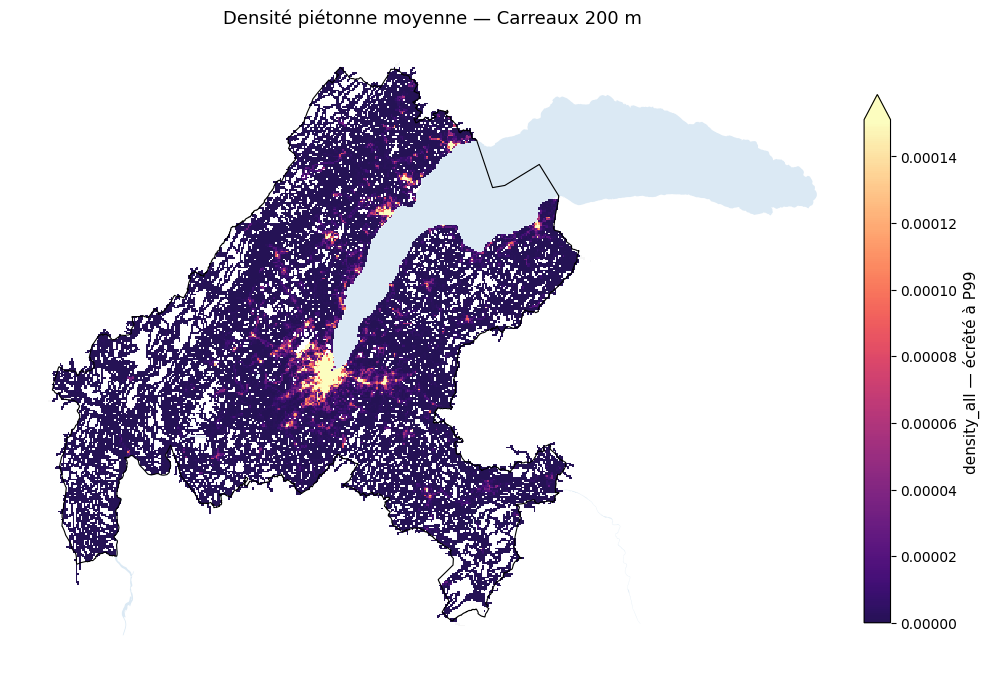

In [16]:
_ = plot_aggregated_density(MESHES["carreau_200"], col=DENSITY_COL, clip_quantile=CLIP_Q,
                            title="Densité piétonne moyenne — Carreaux 200 m",
                            boundary=agglo_GG, lake=lac_leman)

## Bivariate choropleth — densité × walk index (P25/P75)

  Seuils densité calculés sur : zones > 0
  Seuils    density_all : P33 = 7.338e-07 | P66 = 4.311e-06
  Seuils     walk_index : P33 = 0.2188 | P66 = 0.3918
                        1     2     3
walk ↓ / density →                   
3                   12017  1178   706
2                    7557  2203  3749
1                    9677  2367  1468
  → zones critiques (walk=1, density=3) : 1,468


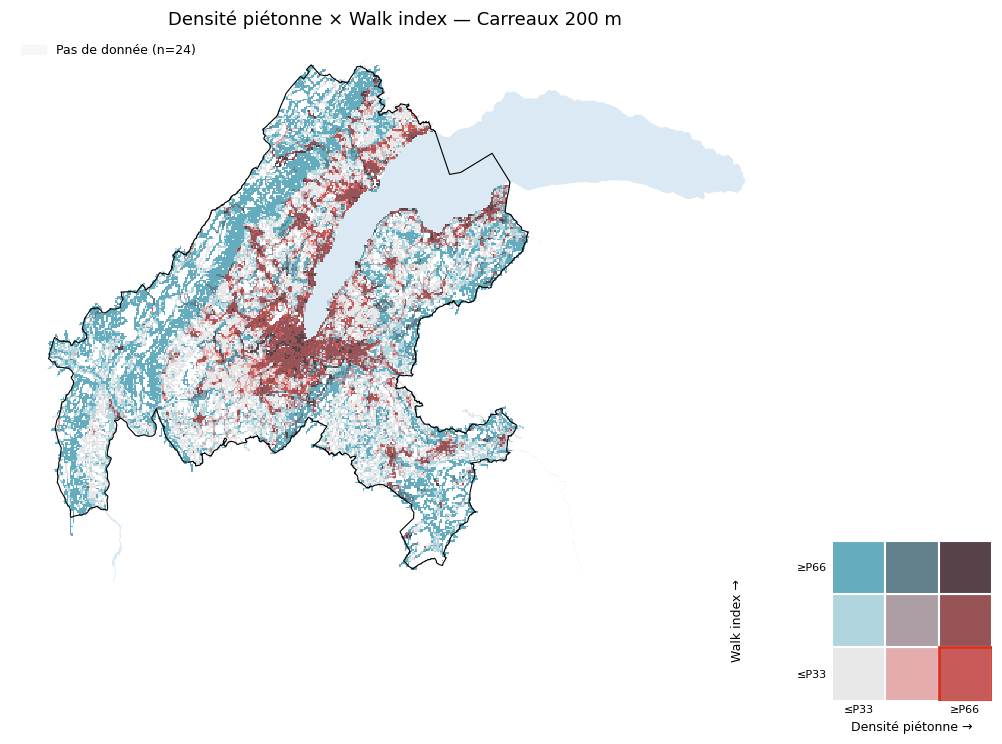

In [17]:
thr_carreau_200 = plot_bivariate_choropleth(MESHES["carreau_200"], DENSITY_COL, WALK_COL, P_LOW, P_HIGH,
                                       title="Densité piétonne × Walk index — Carreaux 200 m",
                                   boundary=agglo_GG,  density_active_only=DENSITY_ACTIVE_ONLY,lake=lac_leman)

## Quadrants — zones critiques (walk index faible & densité forte)

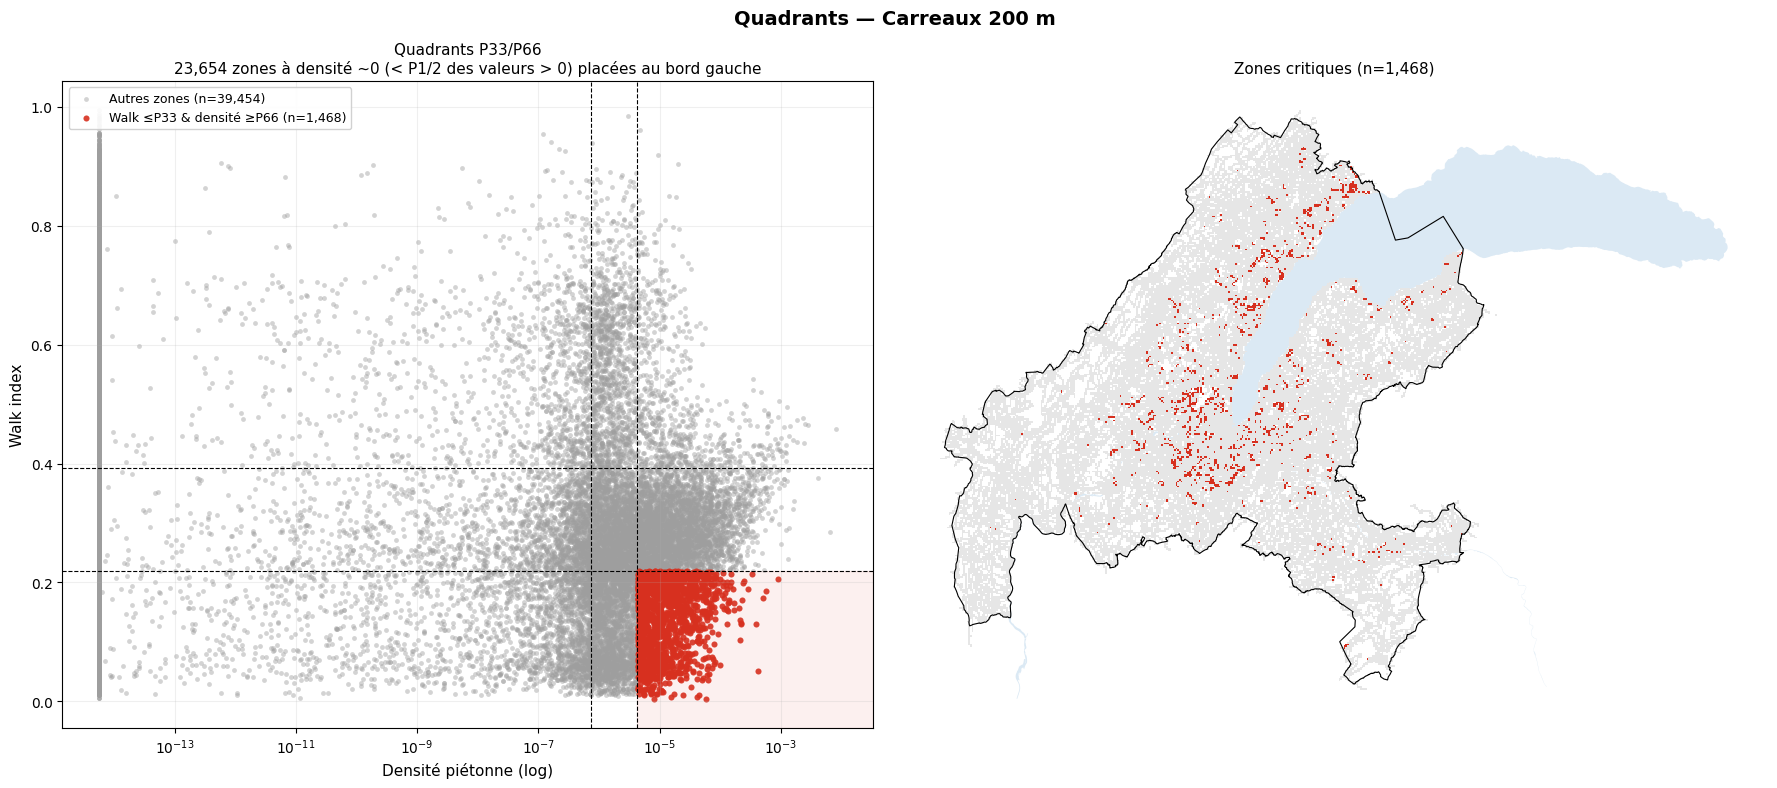

In [18]:
_ = plot_quadrant_scatter_map(MESHES["carreau_200"], DENSITY_COL, WALK_COL, P_LOW, P_HIGH,
                              x_log=True, title="Quadrants — Carreaux 200 m",
                              boundary=agglo_GG, lake=lac_leman, density_active_only=DENSITY_ACTIVE_ONLY, verbose=False)

# ZONES INFRA-COMMUNALES

## Densité agrégée

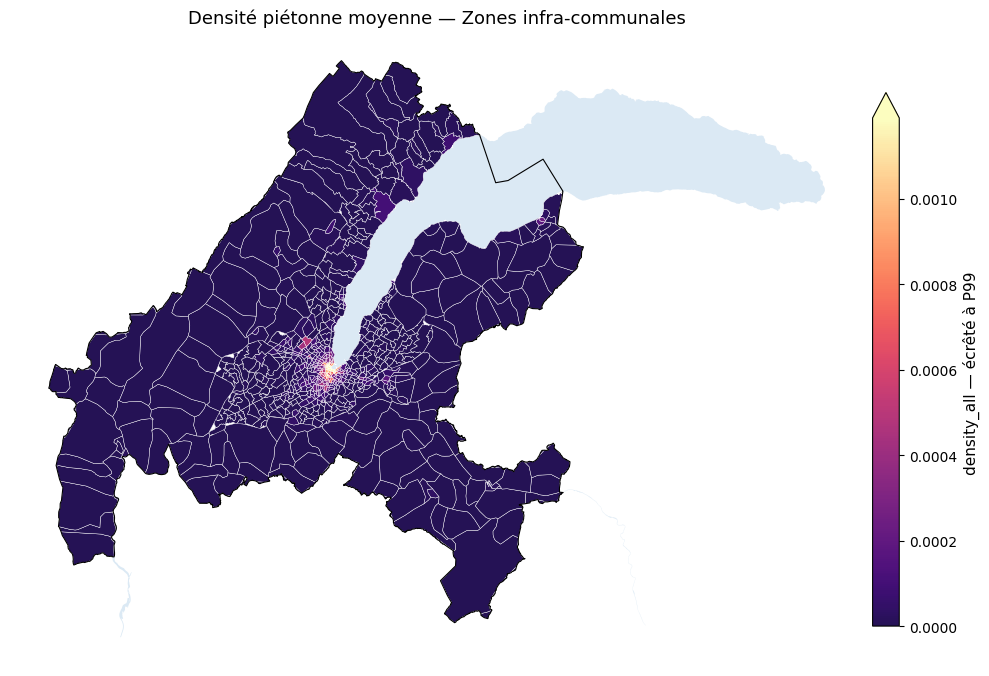

In [19]:
_ = plot_aggregated_density(MESHES["zones_infra"], col=DENSITY_COL, clip_quantile=CLIP_Q,
                            title="Densité piétonne moyenne — Zones infra-communales",
                            boundary=agglo_GG, lake=lac_leman,edgecolor="white", linewidth=0.3)

## Bivariate choropleth — densité × walk index (P25/P75)

  Seuils densité calculés sur : zones > 0
  Seuils    density_all : P33 = 2.86e-06 | P66 = 3.314e-05
  Seuils     walk_index : P33 = 0.2574 | P66 = 0.3246
                      1    2    3
walk ↓ / density →               
3                   120   37   96
2                    55   85  105
1                    97  110   38
  → zones critiques (walk=1, density=3) : 38


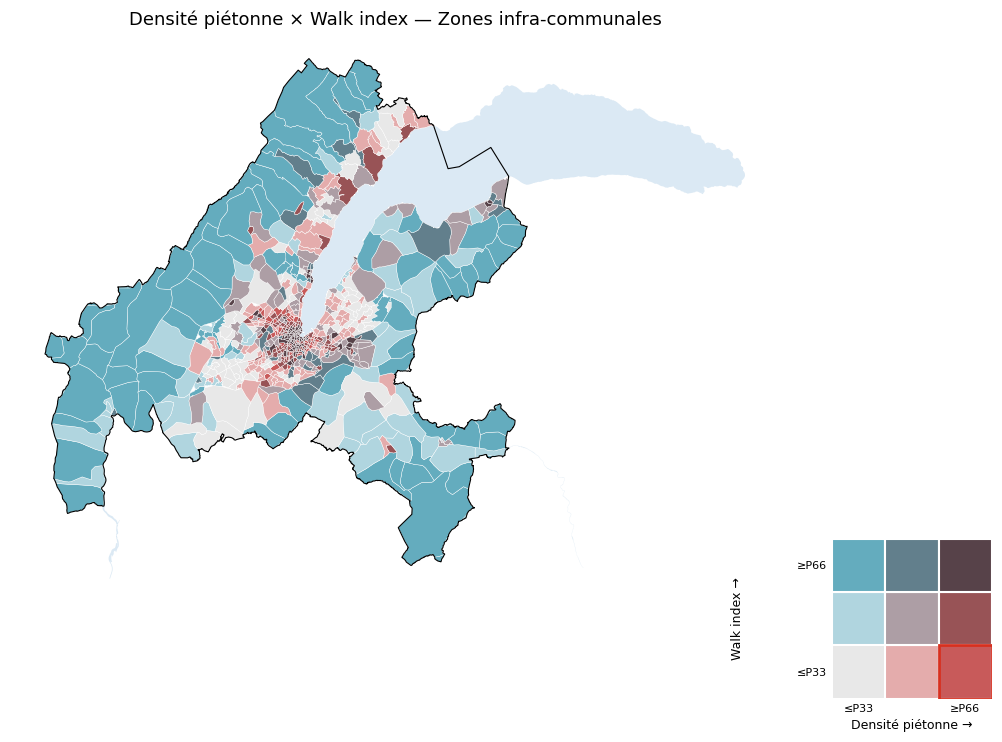

In [20]:
thr_zones_infra = plot_bivariate_choropleth(MESHES["zones_infra"], DENSITY_COL, WALK_COL, P_LOW, P_HIGH,
                                       title="Densité piétonne × Walk index — Zones infra-communales",
                                   boundary=agglo_GG, lake=lac_leman, edgecolor="white",  density_active_only=DENSITY_ACTIVE_ONLY,linewidth=0.3)

## Quadrants — zones critiques (walk index faible & densité forte)

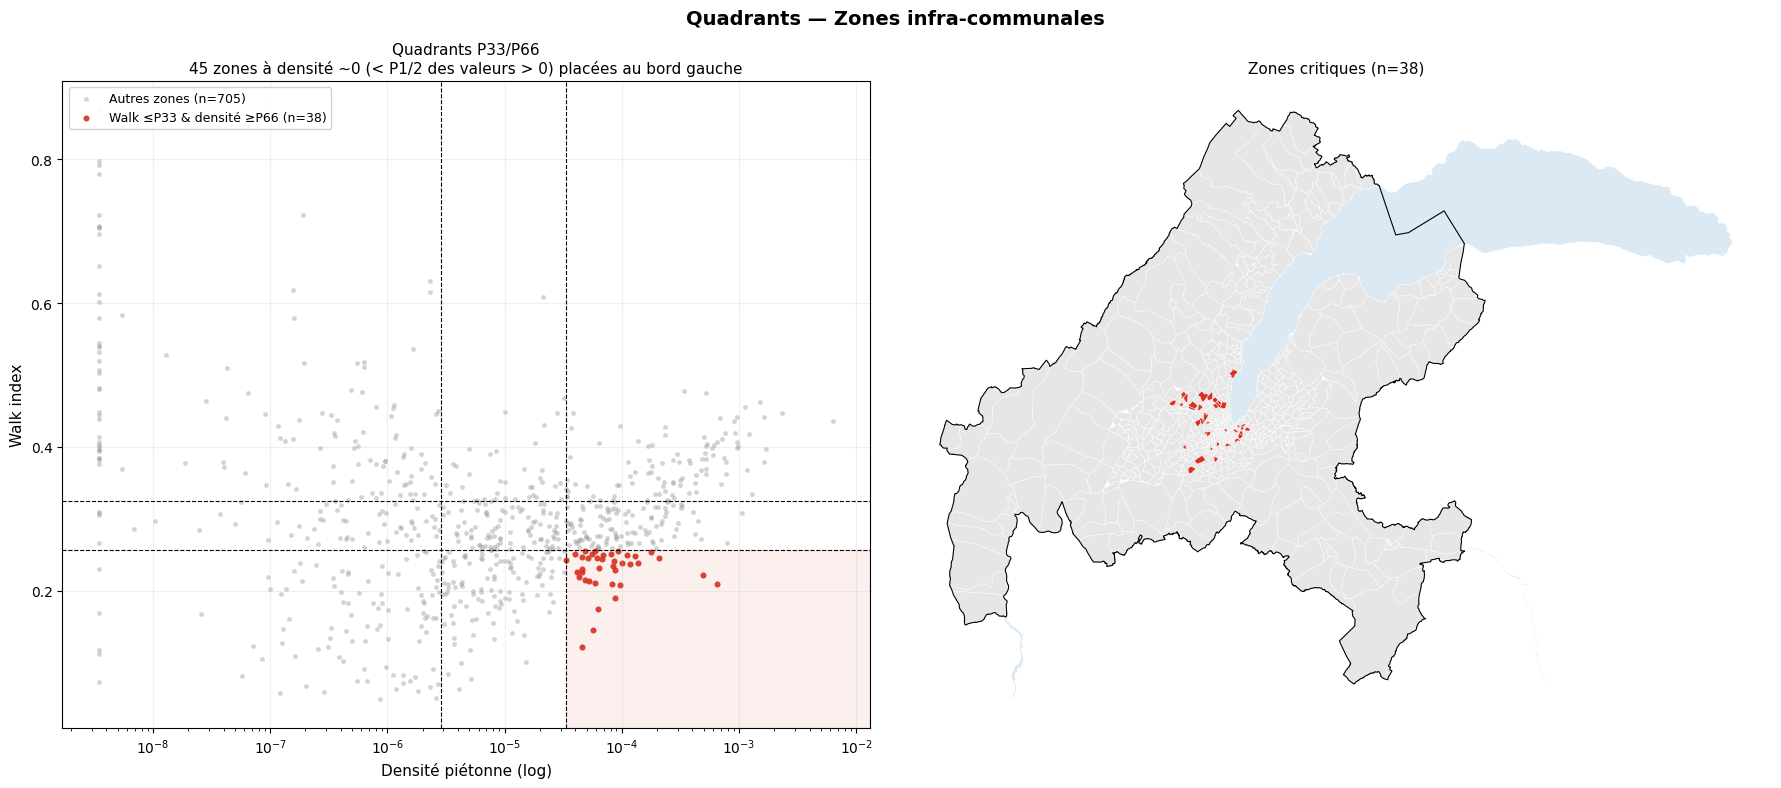

In [21]:
_ = plot_quadrant_scatter_map(MESHES["zones_infra"], DENSITY_COL, WALK_COL, P_LOW, P_HIGH,
                              x_log=True, title="Quadrants — Zones infra-communales",
                              boundary=agglo_GG, lake=lac_leman, edgecolor="white", linewidth=0.3, density_active_only=DENSITY_ACTIVE_ONLY, verbose=False)

# EXPORTS

In [23]:
for name, gdf in MESHES.items():
    export_enriched(gdf, OUTPUT_DIR, f"walk_index_density_{name}", crs=EXPORT_CRS)

  ✓ /Users/maximiliantrique/Documents/GitHub/projet_pieton_gg/Data/output/PL_output/WALK_INDEX_DENSITY/walk_index_density_carreau_200.parquet
  ✓ /Users/maximiliantrique/Documents/GitHub/projet_pieton_gg/Data/output/PL_output/WALK_INDEX_DENSITY/walk_index_density_carreau_200.gpkg  (40,946 zones, EPSG:2056)
  ✓ /Users/maximiliantrique/Documents/GitHub/projet_pieton_gg/Data/output/PL_output/WALK_INDEX_DENSITY/walk_index_density_zones_infra.parquet
  ✓ /Users/maximiliantrique/Documents/GitHub/projet_pieton_gg/Data/output/PL_output/WALK_INDEX_DENSITY/walk_index_density_zones_infra.gpkg  (743 zones, EPSG:2056)


In [22]:
for name, gdf in MESHES.items():
    # recalcul systématique → classes cohérentes avec les paramètres actuels
    add_bivariate_classes(gdf, DENSITY_COL, WALK_COL, P_LOW, P_HIGH,
                          density_active_only=DENSITY_ACTIVE_ONLY, verbose=False)
    critical = gdf[gdf["is_critical"]].copy()
    critical["p_low"], critical["p_high"] = P_LOW, P_HIGH   # traçabilité des seuils
    critical["density_active_only"] = DENSITY_ACTIVE_ONLY
    print(f"── {name} : {len(critical):,} zones critiques / {len(gdf):,}")
    export_enriched(critical, OUTPUT_DIR, f"critical_zones_{name}", crs=EXPORT_CRS)

── carreau_200 : 1,468 zones critiques / 40,946
  ✓ /Users/maximiliantrique/Documents/GitHub/projet_pieton_gg/Data/output/PL_output/WALK_INDEX_DENSITY/critical_zones_carreau_200.parquet
  ✓ /Users/maximiliantrique/Documents/GitHub/projet_pieton_gg/Data/output/PL_output/WALK_INDEX_DENSITY/critical_zones_carreau_200.gpkg  (1,468 zones, EPSG:2056)
── zones_infra : 38 zones critiques / 743
  ✓ /Users/maximiliantrique/Documents/GitHub/projet_pieton_gg/Data/output/PL_output/WALK_INDEX_DENSITY/critical_zones_zones_infra.parquet
  ✓ /Users/maximiliantrique/Documents/GitHub/projet_pieton_gg/Data/output/PL_output/WALK_INDEX_DENSITY/critical_zones_zones_infra.gpkg  (38 zones, EPSG:2056)


## Zones lacunaires vs reste — attributs

Zones lacunaires = `is_critical` (walk index ≤ P_LOW & densité ≥ P_HIGH). Pour chaque attribut : moyenne, std, médiane, Cohen's d et test de Mann-Whitney → CSV + panel de distributions superposées (triées par |d|).  
`walk_index` et `density_all` sont les critères de sélection : leur différence est triviale.

carreau_200 : 1,468 zones lacunaires / 40,946 | 31 attributs
  ✓ /Users/maximiliantrique/Documents/GitHub/projet_pieton_gg/Data/output/PL_output/WALK_INDEX_DENSITY/stats_zones_lacunaires_vs_reste_carreau_200.csv


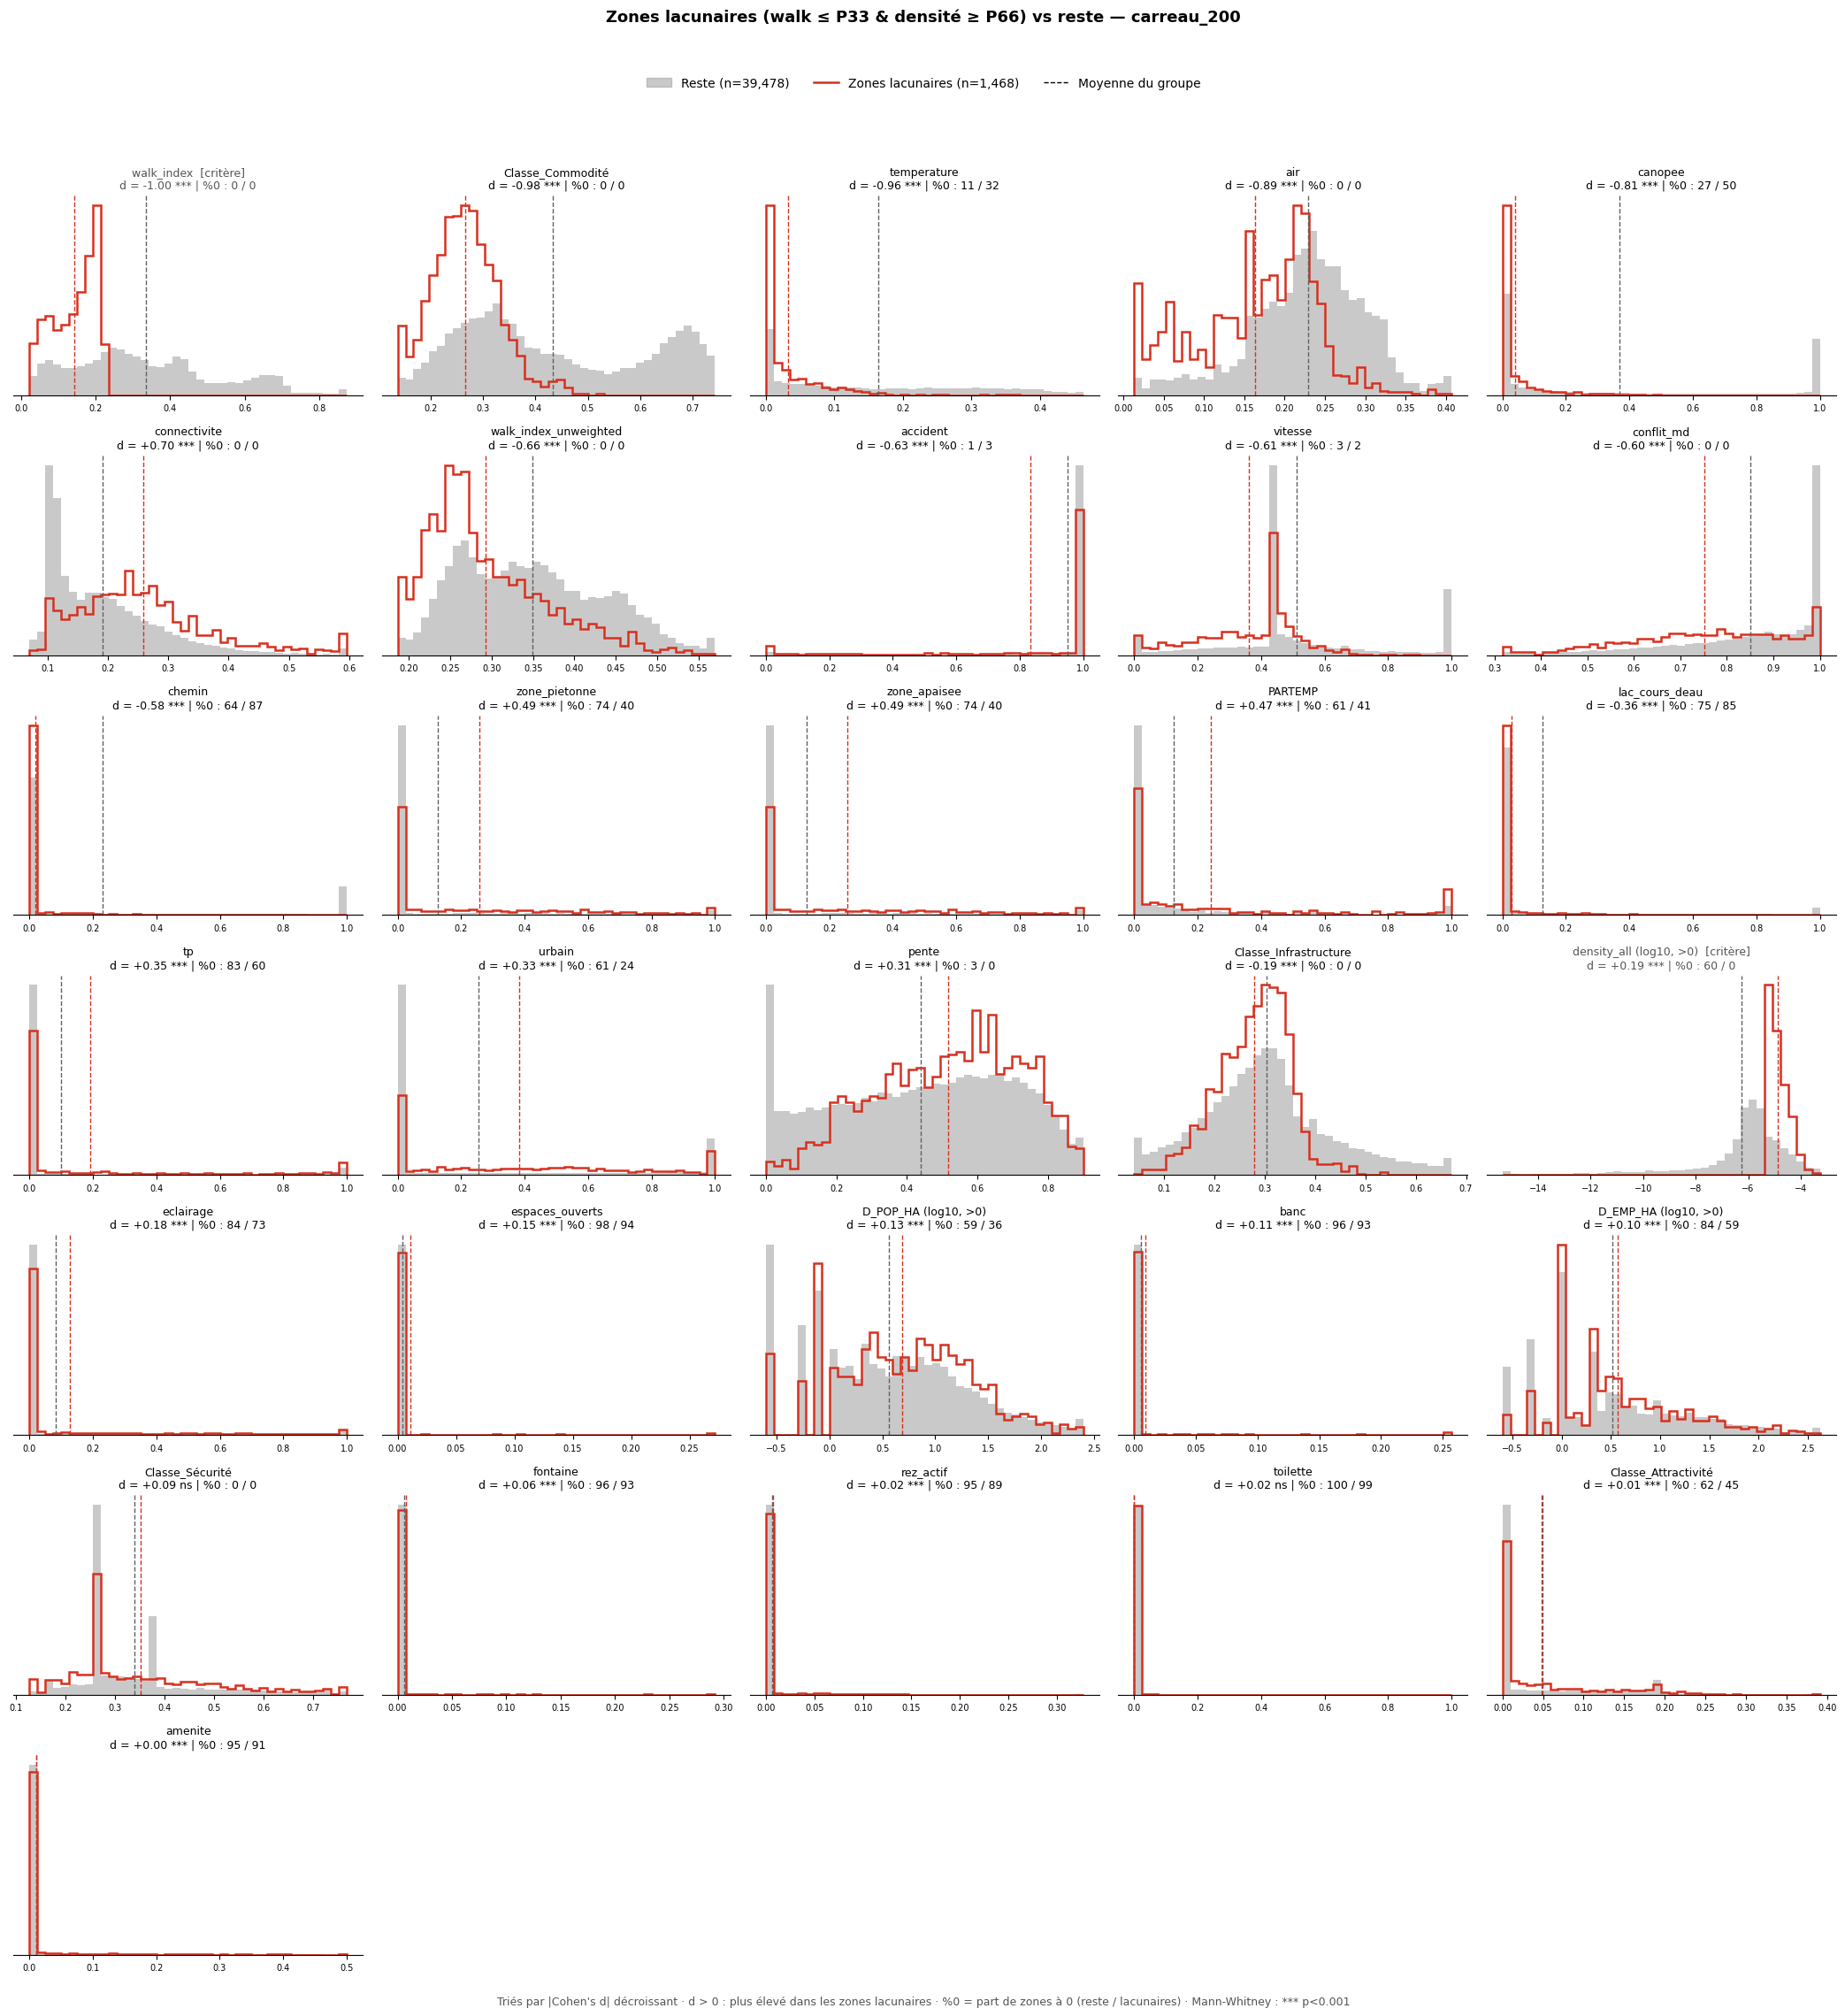

,attribute,mean_normal,std_normal,mean_lacunaire,std_lacunaire,cohen_d,p_mannwhitney
0,walk_index,0.3336,0.1942,0.1417,0.0585,-1.0043,0.0000
1,Classe_Commodité,0.4328,0.1735,0.2662,0.0642,-0.9757,0.0000
2,temperature,0.1644,0.1395,0.0325,0.0526,-0.9597,0.0000
3,air,0.2293,0.0747,0.1631,0.0754,-0.8855,0.0000
4,canopee,0.3687,0.4162,0.0387,0.0830,-0.8067,0.0000
5,connectivite,0.1908,0.0964,0.2584,0.1133,0.6964,0.0000
6,walk_index_unweighted,0.3492,0.0861,0.2922,0.0727,-0.6646,0.0000
7,accident,0.9501,0.1799,0.8323,0.3073,-0.6331,0.0000
8,vitesse,0.5126,0.2528,0.3607,0.1573,-0.6078,0.0000
9,conflit_md,0.8513,0.1652,0.7517,0.1689,-0.6029,0.0000


In [25]:
# ══ ZONES LACUNAIRES vs RESTE — carreaux 200 m ════════════════════════════════
# Zones lacunaires = is_critical (walk index ≤ P_LOW & densité ≥ P_HIGH)
from scipy.stats import mannwhitneyu

MESH_STATS   = "carreau_200"
FLAG_COL     = "is_critical"
CRITERIA     = [WALK_COL, DENSITY_COL]                 # variables de sélection → différence triviale
LOG_ATTRS    = [DENSITY_COL, "D_POP_HA", "D_EMP_HA"]   # affichées en log10 (valeurs > 0)
STATS_EXCLUDE = [                                       # colonnes non pertinentes (identifiants, géométrie, technique)
    "OBJECTID", "GRID_ID", "H_P_REGG", "GEOM_AREA", "GEOM_LEN",
    "POP_TOT_GG", "EMP_TOT_GG", "POP_TOT_00", "EMP_TOT_00",
    "rd_hors_agglo_masked", "rd_hors_agglo_overlap_ratio", "p_low", "p_high",
]


def select_stat_attributes(gdf, exclude=STATS_EXCLUDE):
    """Colonnes numériques pertinentes : exclut identifiants, colonnes techniques du notebook et constantes."""
    tech_prefix = ("n_pixels_", "valid_share_")
    tech_suffix = ("_norm", "_class")
    attrs = []
    for c in gdf.select_dtypes("number").columns:
        if c in exclude or c.startswith(tech_prefix) or c.endswith(tech_suffix):
            continue
        if gdf[c].nunique(dropna=True) <= 1:
            continue
        attrs.append(c)
    return attrs


def compare_groups(gdf, attrs, flag_col=FLAG_COL, criteria=CRITERIA):
    """Moyenne / std / médiane par groupe + écart, Cohen's d et test de Mann-Whitney."""
    g_lac, g_norm = gdf[gdf[flag_col]], gdf[~gdf[flag_col]]
    rows = []
    for a in attrs:
        x_n, x_l = g_norm[a].dropna(), g_lac[a].dropna()
        m_n, m_l, s_n, s_l = x_n.mean(), x_l.mean(), x_n.std(), x_l.std()
        pooled = np.sqrt(((len(x_n) - 1) * s_n**2 + (len(x_l) - 1) * s_l**2) / max(len(x_n) + len(x_l) - 2, 1))
        p = mannwhitneyu(x_l, x_n).pvalue if len(x_l) and len(x_n) else np.nan
        rows.append({
            "attribute": a,
            "n_normal": len(x_n),      "mean_normal": m_n,     "std_normal": s_n,     "median_normal": x_n.median(),
            "n_lacunaire": len(x_l),   "mean_lacunaire": m_l,  "std_lacunaire": s_l,  "median_lacunaire": x_l.median(),
            "delta_mean": m_l - m_n,
            "ratio_mean": m_l / m_n if m_n != 0 else np.nan,
            "cohen_d": (m_l - m_n) / pooled if pooled > 0 else np.nan,
            "pct_zero_normal": (x_n == 0).mean() * 100, "pct_zero_lacunaire": (x_l == 0).mean() * 100,
            "p_mannwhitney": p,
            "selection_criterion": a in criteria,
        })
    df = pd.DataFrame(rows)
    return df.reindex(df["cohen_d"].abs().sort_values(ascending=False).index).reset_index(drop=True)


def plot_group_distributions(gdf, df_stats, flag_col=FLAG_COL, log_attrs=LOG_ATTRS,
                             ncols=5, bins=40, title=None):
    """Grand panel : distributions superposées (reste en gris, zones lacunaires en rouge), normalisées."""
    attrs = df_stats["attribute"].tolist()
    nrows = int(np.ceil(len(attrs) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.1 * nrows))
    axes = np.atleast_1d(axes).ravel()
    lac = gdf[flag_col]

    for ax, (_, r) in zip(axes, df_stats.iterrows()):
        a = r["attribute"]
        x_n, x_l = gdf.loc[~lac, a].dropna(), gdf.loc[lac, a].dropna()
        is_log = a in log_attrs
        if is_log:
            x_n, x_l = np.log10(x_n[x_n > 0]), np.log10(x_l[x_l > 0])
        both = pd.concat([x_n, x_l])
        if both.empty:
            ax.set_axis_off(); continue
        lo, hi = both.quantile([0.005, 0.995])
        if lo == hi:
            lo, hi = both.min(), both.max() + 1e-9
        edges = np.linspace(lo, hi, bins + 1)
        ax.hist(x_n.clip(lo, hi), bins=edges, density=True, color="#9e9e9e", alpha=0.55, label="Reste")
        ax.hist(x_l.clip(lo, hi), bins=edges, density=True, histtype="step", linewidth=1.8,
                color=CRITICAL_COLOR, label="Lacunaires")
        ax.axvline(x_n.mean(), color="#616161", linestyle="--", linewidth=1)
        ax.axvline(x_l.mean(), color=CRITICAL_COLOR, linestyle="--", linewidth=1)

        star = "***" if r["p_mannwhitney"] < 1e-3 else "**" if r["p_mannwhitney"] < 1e-2 else \
               "*" if r["p_mannwhitney"] < 0.05 else "ns"
        crit = "  [critère]" if r["selection_criterion"] else ""
        ax.set_title(f"{a}{' (log10, >0)' if is_log else ''}{crit}\n"
                     f"d = {r['cohen_d']:+.2f} {star} | %0 : {r['pct_zero_normal']:.0f} / {r['pct_zero_lacunaire']:.0f}",
                     fontsize=9, color="#555" if r["selection_criterion"] else "black")
        ax.tick_params(labelsize=7)
        ax.set_yticks([])
        for s in ("top", "right", "left"):
            ax.spines[s].set_visible(False)

    for ax in axes[len(attrs):]:
        ax.set_axis_off()

    handles = [mpatches.Patch(color="#9e9e9e", alpha=0.55, label=f"Reste (n={(~lac).sum():,})"),
               Line2D([], [], color=CRITICAL_COLOR, linewidth=1.8, label=f"Zones lacunaires (n={lac.sum():,})"),
               Line2D([], [], color="black", linestyle="--", linewidth=1, label="Moyenne du groupe")]
    fig.legend(handles=handles, loc="upper center", ncol=3, fontsize=10, frameon=False, bbox_to_anchor=(0.5, 1.0))
    fig.suptitle(title or "", fontsize=13, fontweight="bold", y=1.03)
    fig.text(0.5, -0.01, "Triés par |Cohen's d| décroissant · d > 0 : plus élevé dans les zones lacunaires · "
             "%0 = part de zones à 0 (reste / lacunaires) · Mann-Whitney : *** p<0.001",
             ha="center", fontsize=9, color="#555")
    plt.tight_layout(rect=(0, 0, 1, 0.97))
    return fig


# ─── Calcul ──────────────────────────────────────────────────────────────────
gdf_stats = MESHES[MESH_STATS]
add_bivariate_classes(gdf_stats, DENSITY_COL, WALK_COL, P_LOW, P_HIGH,
                      density_active_only=DENSITY_ACTIVE_ONLY, verbose=False)
attrs = select_stat_attributes(gdf_stats)
df_lac = compare_groups(gdf_stats, attrs)
print(f"{MESH_STATS} : {gdf_stats[FLAG_COL].sum():,} zones lacunaires / {len(gdf_stats):,} | {len(attrs)} attributs")

# ─── Export CSV ──────────────────────────────────────────────────────────────
os.makedirs(OUTPUT_DIR, exist_ok=True)
csv_path = os.path.join(OUTPUT_DIR, f"stats_zones_lacunaires_vs_reste_{MESH_STATS}.csv")
df_lac.to_csv(csv_path, index=False)
print(f"  ✓ {csv_path}")

# ─── Panel ───────────────────────────────────────────────────────────────────
fig = plot_group_distributions(
    gdf_stats, df_lac,
    title=f"Zones lacunaires (walk ≤ P{P_LOW} & densité ≥ P{P_HIGH}) vs reste — {MESH_STATS}")
fig.savefig(os.path.join(OUTPUT_DIR, f"distributions_zones_lacunaires_vs_reste_{MESH_STATS}.png"),
            dpi=150, bbox_inches="tight")
plt.show()

df_lac[["attribute", "mean_normal", "std_normal", "mean_lacunaire", "std_lacunaire",
        "cohen_d", "p_mannwhitney"]].round(4)
